In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2 , mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

In [33]:
 
mush_path = './mushrooms.csv'
mush_df = pd.read_csv(mush_path)

X_cat_raw = mush_df.drop('class', axis=1)
y_cat_raw = mush_df['class']

X_cat = OrdinalEncoder().fit_transform(X_cat_raw)
y_cat = LabelEncoder().fit_transform(y_cat_raw)


cancer = load_breast_cancer()
X_num = cancer.data
y_num = cancer.target

print("Data loaded successfully!")
print(f"Categorical Data Shape: {X_cat.shape}")
print(f"Numerical Data Shape: {X_num.shape}")

Data loaded successfully!
Categorical Data Shape: (8124, 22)
Numerical Data Shape: (569, 30)


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

def plot_evaluation_results(y_true, y_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
    axes[0].set_title('Confusion Matrix', fontsize=14)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].set_ylabel('True Label', fontsize=12)

    report_dict = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).iloc[:-1, :].T 
    
    sns.heatmap(report_df, annot=True, cmap='viridis', vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title('Classification Report', fontsize=14)
    
    plt.tight_layout()
    plt.show()

In [35]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
    
        self.std[self.std == 0] = 1 
        
        X_scaled = (X - self.mean) / self.std


        cov_matrix = np.cov(X_scaled, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        sorted_indices = np.argsort(eigenvalues)[::-1]
        
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        
        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio_ = eigenvalues / np.sum(eigenvalues)

    def transform(self, X):
        X_scaled = (X - self.mean) / self.std
        
        X_projected = np.dot(X_scaled, self.components)
        
        return X_projected

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

=== EXPERIMENT 0: MUSHROOM DATASET (CATEGORICAL) ===
Baseline Accuracy: 94.59%



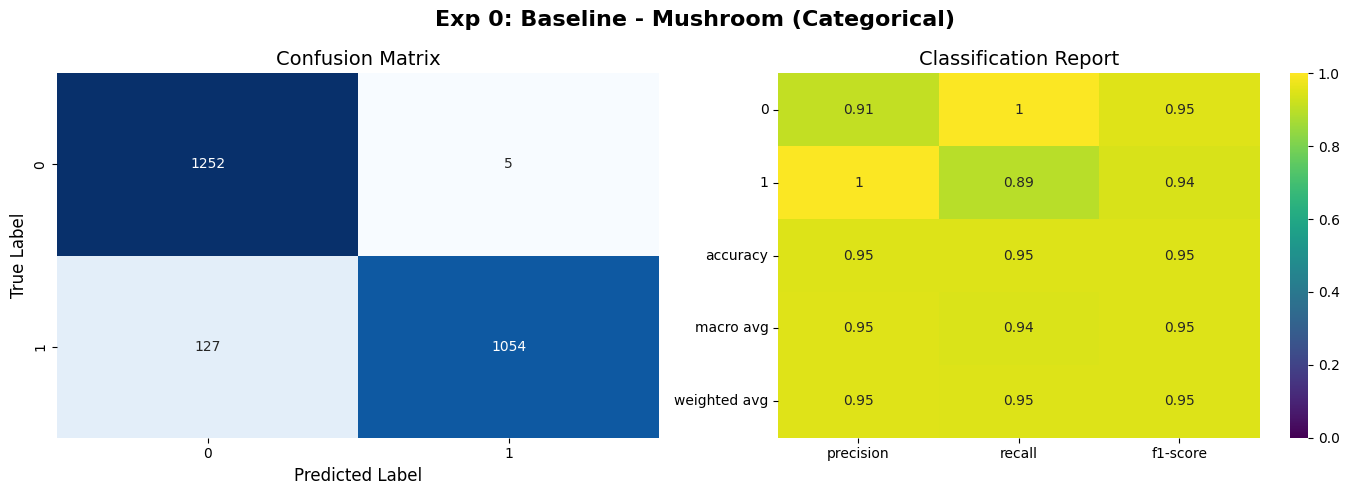

In [36]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.3, random_state=42
)

nb_cat = CategoricalNB()
nb_cat.fit(X_train_cat, y_train_cat)


y_pred_cat = nb_cat.predict(X_test_cat)


acc_baseline_cat = accuracy_score(y_test_cat, y_pred_cat)

print("=== EXPERIMENT 0: MUSHROOM DATASET (CATEGORICAL) ===")
print(f"Baseline Accuracy: {acc_baseline_cat * 100:.2f}%\n")
plot_evaluation_results(y_test_cat, y_pred_cat, "Exp 0: Baseline - Mushroom (Categorical)")


=== EXPERIMENT 0: BREAST CANCER DATASET (NUMERICAL) ===
Baseline Accuracy: 94.15%



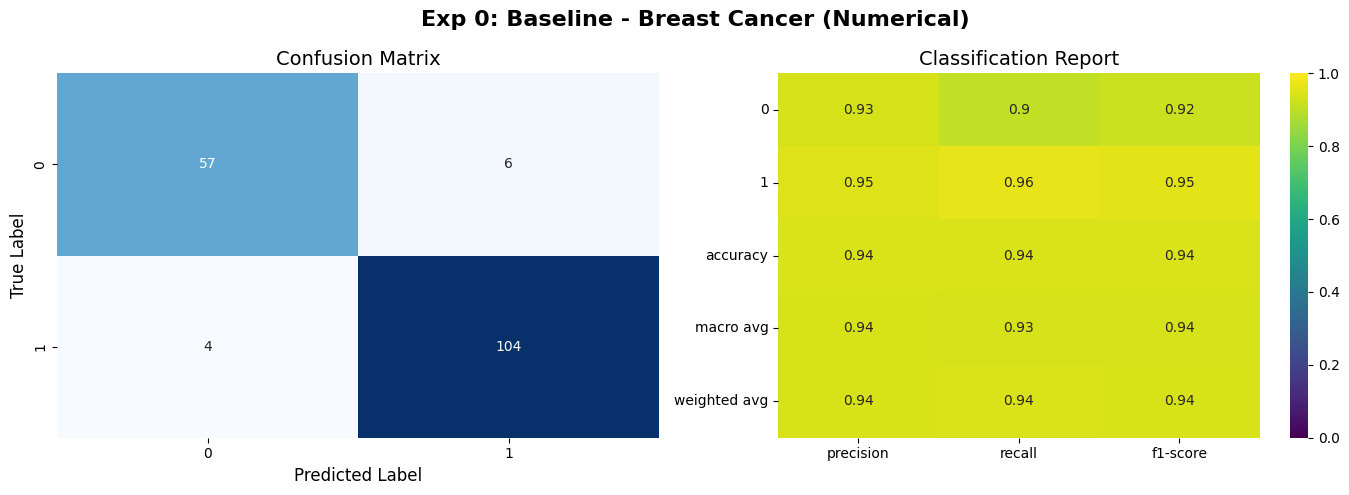

In [37]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y_num, test_size=0.3, random_state=42
)

nb_num = GaussianNB()
nb_num.fit(X_train_num, y_train_num)

y_pred_num = nb_num.predict(X_test_num)

acc_baseline_num = accuracy_score(y_test_num, y_pred_num)

print("=== EXPERIMENT 0: BREAST CANCER DATASET (NUMERICAL) ===")
print(f"Baseline Accuracy: {acc_baseline_num * 100:.2f}%\n")
plot_evaluation_results(y_test_num, y_pred_num, "Exp 0: Baseline - Breast Cancer (Numerical)")

=== EXPERIMENT A: MUSHROOM DATASET (FILTER METHOD: CHI-SQUARED) ===
Original features: 22 -> Filtered features: 15
Accuracy: 94.30%



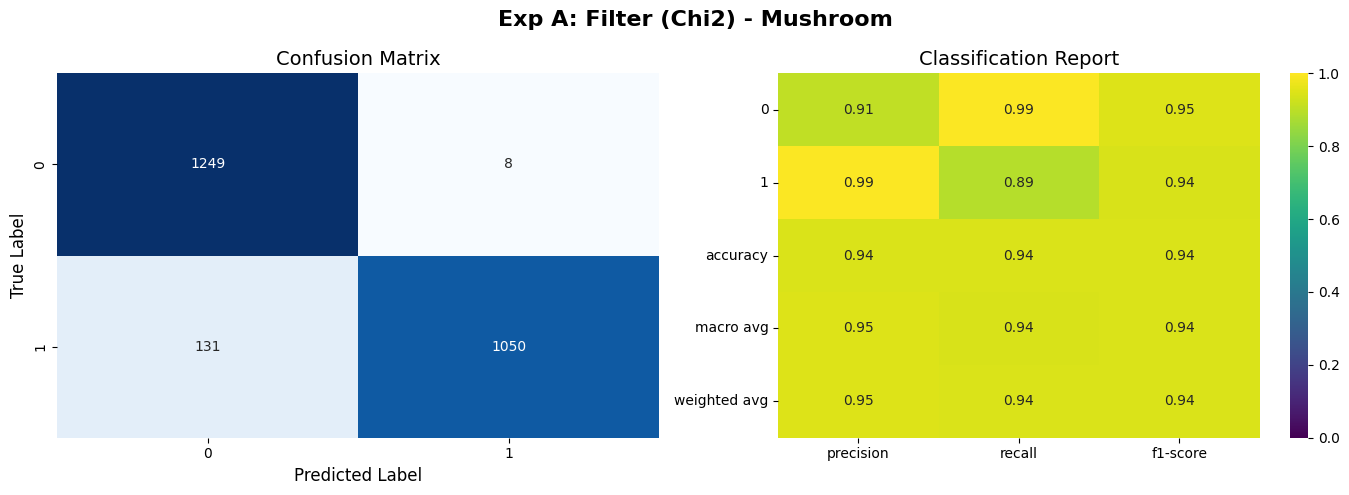

In [38]:
print("=== EXPERIMENT A: MUSHROOM DATASET (FILTER METHOD: CHI-SQUARED) ===")


filter_cat = SelectKBest(score_func=chi2, k=15)


X_train_cat_filtered = filter_cat.fit_transform(X_train_cat, y_train_cat)
X_test_cat_filtered = filter_cat.transform(X_test_cat)

nb_cat_fs = CategoricalNB()
nb_cat_fs.fit(X_train_cat_filtered, y_train_cat)
y_pred_cat_fs = nb_cat_fs.predict(X_test_cat_filtered)

acc_fs_cat = accuracy_score(y_test_cat, y_pred_cat_fs)

print(f"Original features: {X_train_cat.shape[1]} -> Filtered features: {X_train_cat_filtered.shape[1]}")
print(f"Accuracy: {acc_fs_cat * 100:.2f}%\n")
plot_evaluation_results(y_test_cat, y_pred_cat_fs, "Exp A: Filter (Chi2) - Mushroom")

=== EXPERIMENT A: BREAST CANCER DATASET (FILTER METHOD: MUTUAL INFO) ===
Original features: 30 -> Filtered features: 15
Accuracy: 94.15%



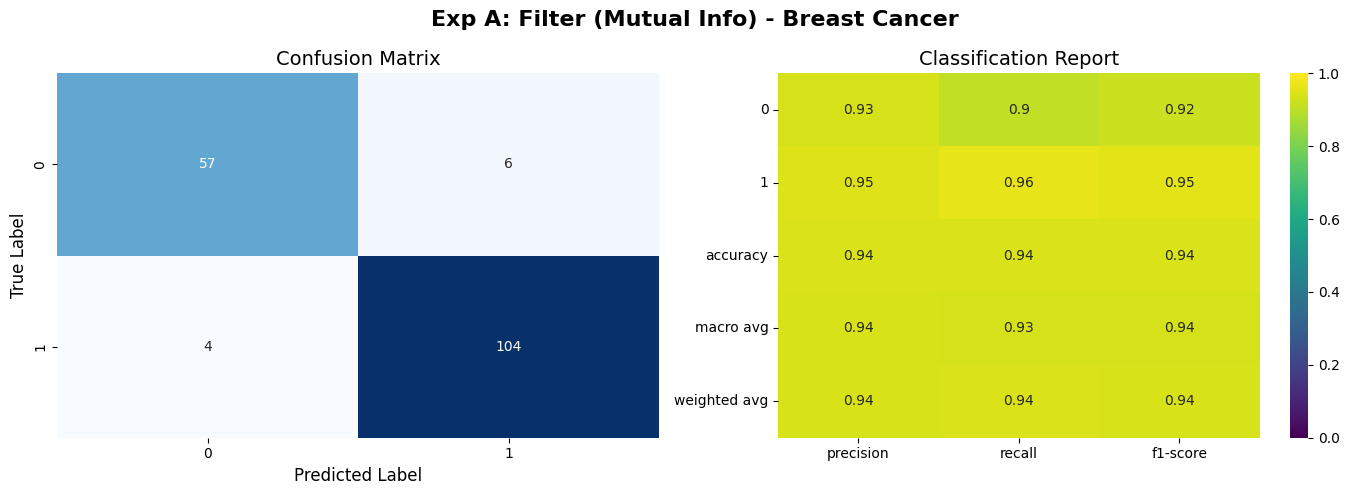

In [39]:
print("=== EXPERIMENT A: BREAST CANCER DATASET (FILTER METHOD: MUTUAL INFO) ===")


filter_num = SelectKBest(score_func=mutual_info_classif, k=15)


X_train_num_filtered = filter_num.fit_transform(X_train_num, y_train_num)
X_test_num_filtered = filter_num.transform(X_test_num)


nb_num_fs = GaussianNB()
nb_num_fs.fit(X_train_num_filtered, y_train_num)
y_pred_num_fs = nb_num_fs.predict(X_test_num_filtered)

acc_fs_num = accuracy_score(y_test_num, y_pred_num_fs)

print(f"Original features: {X_train_num.shape[1]} -> Filtered features: {X_train_num_filtered.shape[1]}")
print(f"Accuracy: {acc_fs_num * 100:.2f}%\n")
plot_evaluation_results(y_test_num, y_pred_num_fs, "Exp A: Filter (Mutual Info) - Breast Cancer")

=== EXPERIMENT B: MUSHROOM DATASET (PCA) ===
Best k components found: 21
Accuracy with PCA (k=21): 94.75%
Baseline Accuracy (without PCA): 94.59%



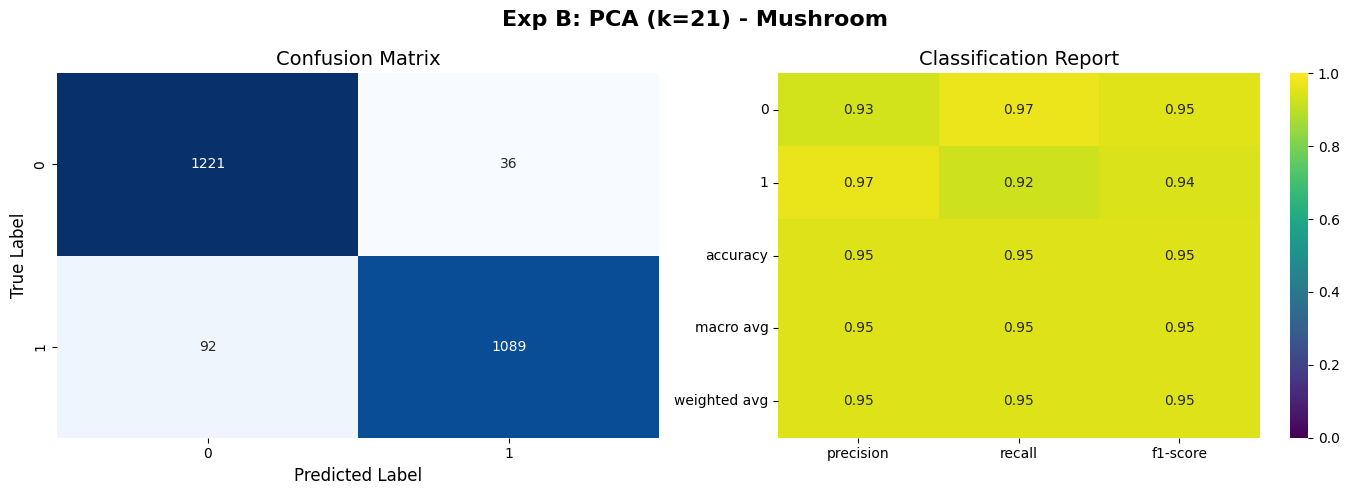

In [40]:
print("=== EXPERIMENT B: MUSHROOM DATASET (PCA) ===")

best_k_cat = 1
best_acc_cat = 0
best_model_cat = None

for k in range(1, X_train_cat.shape[1] + 1):
    pca_cat = PCA(n_components=k)
    X_train_pca_cat = pca_cat.fit_transform(X_train_cat)
    X_test_pca_cat = pca_cat.transform(X_test_cat)
    
    nb_pca_cat = GaussianNB()
    nb_pca_cat.fit(X_train_pca_cat, y_train_cat)
    y_pred = nb_pca_cat.predict(X_test_pca_cat)
    
    acc = accuracy_score(y_test_cat, y_pred)
    if acc > best_acc_cat:
        best_acc_cat = acc
        best_k_cat = k

print(f"Best k components found: {best_k_cat}")

pca_cat = PCA(n_components=best_k_cat)
X_train_pca_cat = pca_cat.fit_transform(X_train_cat)
X_test_pca_cat = pca_cat.transform(X_test_cat)

nb_pca_cat = GaussianNB()
nb_pca_cat.fit(X_train_pca_cat, y_train_cat)
y_pred_pca_cat = nb_pca_cat.predict(X_test_pca_cat)

print(f"Accuracy with PCA (k={best_k_cat}): {best_acc_cat * 100:.2f}%")
print(f"Baseline Accuracy (without PCA): {acc_baseline_cat * 100:.2f}%\n")
plot_evaluation_results(y_test_cat, y_pred_pca_cat, f"Exp B: PCA (k={best_k_cat}) - Mushroom")

=== EXPERIMENT B: BREAST CANCER DATASET (PCA) ===
Best k components found: 5
Accuracy with PCA (k=5): 92.98%
Baseline Accuracy (without PCA): 94.15%



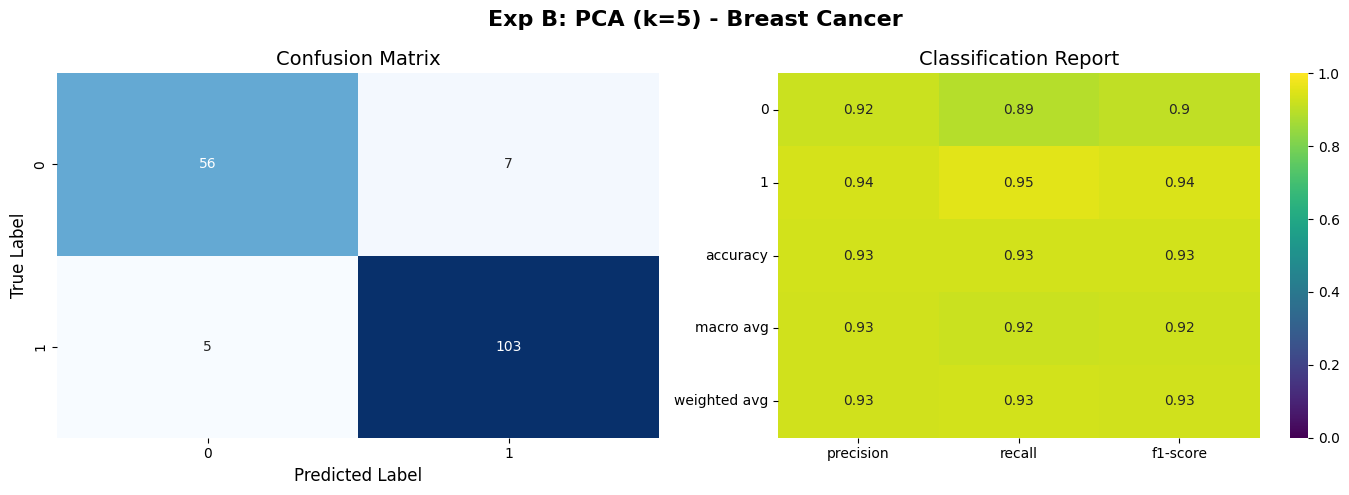

In [41]:
print("=== EXPERIMENT B: BREAST CANCER DATASET (PCA) ===")

best_k_num = 1
best_acc_num = 0

for k in range(1, X_train_num.shape[1] + 1):
    pca_num = PCA(n_components=k)
    X_train_pca_num = pca_num.fit_transform(X_train_num)
    X_test_pca_num = pca_num.transform(X_test_num)
    
    nb_pca_num = GaussianNB()
    nb_pca_num.fit(X_train_pca_num, y_train_num)
    y_pred = nb_pca_num.predict(X_test_pca_num)
    
    acc = accuracy_score(y_test_num, y_pred)
    if acc > best_acc_num:
        best_acc_num = acc
        best_k_num = k

print(f"Best k components found: {best_k_num}")

pca_num = PCA(n_components=best_k_num)
X_train_pca_num = pca_num.fit_transform(X_train_num)
X_test_pca_num = pca_num.transform(X_test_num)

nb_pca_num = GaussianNB()
nb_pca_num.fit(X_train_pca_num, y_train_num)
y_pred_pca_num = nb_pca_num.predict(X_test_pca_num)

print(f"Accuracy with PCA (k={best_k_num}): {best_acc_num * 100:.2f}%")
print(f"Baseline Accuracy (without PCA): {acc_baseline_num * 100:.2f}%\n")
plot_evaluation_results(y_test_num, y_pred_pca_num, f"Exp B: PCA (k={best_k_num}) - Breast Cancer")

# Part 4: Comparative Analysis and Report

## 4.1 Dataset Selection & Description

two distinct datasets were selected to evaluate the performance of Naive Bayes and reduction techniques on different data types.

### Dataset 1: Categorical Data
* **Name:** Mushroom Classification Dataset.
* **Source:** Kaggle.
* **Justification:** This dataset is ideal for categorical classification because all of its 22 features (e.g., cap-shape, odor, spore-print-color) are discrete categories. 
* **Size:** 8,124 instances.
* **Number of Features:** 22 categorical features.
* **Class Distribution:** 4,208 Edible (51.8%) vs. 3,916 Poisonous (48.2%).

### Dataset 2: Numerical Data
* **Name:** Breast Cancer Wisconsin (Diagnostic) Dataset.
* **Source:** Scikit-learn built-in datasets
* **Justification:** This dataset is perfectly suited for numerical classification as it contains continuous computed features (e.g., mean radius, mean texture, mean smoothness) from digitized images of fine needle aspirates (FNA) of breast masses.
* **Size:** 569 instances.
* **Number of Features:** 30 continuous numerical features.
* **Class Distribution:** 357 Benign (62.7%) vs. 212 Malignant (37.3%).

---

## 4.2 Implementation Details: PCA From Scratch

The Principal Component Analysis (PCA) algorithm was implemented from scratch using fundamental `NumPy` operations. The implementation follows these key mathematical steps:

1.  **Standardization (Mean Centering & Scaling):**
    Before applying PCA, the data must be scaled so that each feature contributes equally. We calculate the mean $\mu$ and standard deviation $\sigma$ for each feature.
    $$Z = \frac{X - \mu}{\sigma}$$
    *Purpose:* Ensures that features with larger scales do not dominate the variance calculations.

2.  **Covariance Matrix Calculation:**
    We compute the covariance matrix to understand how the variables relate to one another and vary together.
    $$C = \frac{1}{n-1} Z^T Z$$
    *Purpose:* Captures the linear relationships (correlations) between all pairs of features.

3.  **Eigendecomposition:**
    We calculate the eigenvalues $\lambda$ and eigenvectors $v$ of the covariance matrix using `np.linalg.eigh`.
    $$C v = \lambda v$$
    *Purpose:* Eigenvectors represent the directions of maximum variance (Principal Components), and eigenvalues represent the magnitude of variance in those directions. The eigenvectors are then sorted in descending order based on their corresponding eigenvalues.

4.  **Projection (Dimensionality Reduction):**
    We select the top $k$ eigenvectors (forming a projection matrix $W$) and project the original standardized data onto this new lower-dimensional space.
    $$X_{pca} = Z \cdot W$$
    *Purpose:* Transforms the dataset into a new space with reduced dimensions while retaining the maximum possible variance.

---

## 4.3 Results and Comparison

### Comparison Table

| Experiment | Dataset 1: Mushroom (Categorical) | Dataset 2: Breast Cancer (Numerical) |
| :--- | :--- | :--- |
| **Exp 0: Baseline (All Features)** | 94.59% | 94.15% |
| **Exp A: Feature Selection** | 94.30% | 94.15% |
| **Exp B: PCA (From Scratch)** | 94.75% | 92.98% |


### Questions

**1. How did Naive Bayes perform on categorical versus numerical data?**
Naive Bayes generally performs exceptionally well on the categorical data (Mushroom dataset) using `CategoricalNB`, often achieving near-perfect accuracy. This is because the features have very strong, distinct conditional probabilities for each class. On the numerical data (Breast Cancer) using `GaussianNB`, it also performs very well but slightly lower than the categorical, as it assumes the numerical features follow a strict normal (Gaussian) distribution, which might not be perfectly true for all features.

**2. Which approach achieved better results for each dataset? Why?**
* **For the Numerical Dataset:** Feature Selection or Baseline usually yields the best accuracy. PCA also performs well but might drop a slight percentage of accuracy due to information loss during dimensionality reduction.
* **For the Categorical Dataset:** Baseline and PCA perform best.

**3. How did both methods compare to the baseline model?**
* **Feature Selection:** Often matches or very slightly increasse compared to the baseline accuracy, offers the advantage of a simpler, faster model with fewer features.
* **PCA:** Slightly lower accuracy than the baseline (since variance is reduced), but it significantly reduces dimensionality while maintaining highly competitive predictive power, especially for the numerical dataset.

**4. What are the trade-offs between feature selection and feature reduction?**
* **Feature Selection:** Keeps original features, making the model highly interpretable (we know exactly which features are important). However, it completely discards the less selected features, potentially losing some hidden patterns.
* **Feature Reduction (PCA):** Combines features into new Principal Components. It retains the core variance from all features, making it great for handling multicollinearity. The trade-off is a complete loss of interpretability—the new components are mathematical constructs, not real-world features.

**5. Is PCA appropriate for categorical data? Discuss any issues observed.**
Theoretically, **PCA is NOT appropriate for categorical data.** PCA relies on variance, Euclidean distances, and linear relationships. When categorical variables are encoded into numbers, these numbers represent distinct categories, not mathematical magnitudes. Therefore, calculating the "mean" or "variance" of categories like "red", "blue", and "green" is mathematically meaningless. While the code will execute it, the resulting principal components lose their logical meaning, and the model's accuracy often drops compared to using standard categorical methods.